# Seaborn Tutorial

Seaborn is a Python data visualization library built on top of Matplotlib.

Advantages:
- Better default styling
- Attractive color palettes
- Statistical visualizations
- Less code compared to Matplotlib
- Works directly with Pandas DataFrames

In this notebook we will learn:

1. Themes & Styles
2. Color Palettes
3. Scatter Plot
4. Line Plot
5. Histogram
6. Box Plot
7. Violin Plot
8. Count Plot
9. Bar Plot with Hue
10. Heatmap
11. Pair Plot
12. Visualization Best Practices
13. Color Accessibility

In [4]:
# Import pandas
import pandas as pd

# Import seaborn
import seaborn as sns

# Import matplotlib
import matplotlib.pyplot as plt

# Display plots inside notebook
%matplotlib inline

In [5]:
# Load dataset
df = pd.read_csv("data.csv")

# Display first rows
df.head()

,Duration,Pulse,Maxpulse,Calories
0,60,110,130,409.1
1,60,117,145,479.0
2,60,103,135,340.0
3,45,109,175,282.4
4,45,117,148,406.0


In [6]:
# Dataset shape
print("Rows and Columns:", df.shape)

# Data types
df.info()

# Statistical summary
df.describe()

Rows and Columns: (169, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  169 non-null    int64  
 1   Pulse     169 non-null    int64  
 2   Maxpulse  169 non-null    int64  
 3   Calories  164 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 5.4 KB


,Duration,Pulse,Maxpulse,Calories
count,169.000000,169.000000,169.000000,164.000000
mean,63.846154,107.461538,134.047337,375.790244
std,42.299949,14.510259,16.450434,266.379919
min,15.000000,80.000000,100.000000,50.300000
25%,45.000000,100.000000,124.000000,250.925000
50%,60.000000,105.000000,131.000000,318.600000
75%,60.000000,111.000000,141.000000,387.600000
max,300.000000,159.000000,184.000000,1860.400000


# SECTION 1: THEMES

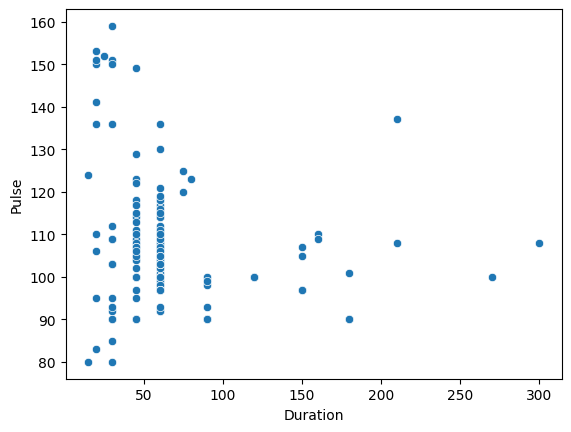

In [7]:
# Simple scatterplot using default theme

sns.scatterplot(
    data=df,
    x=df.columns[0],
    y=df.columns[1]
)

plt.show()

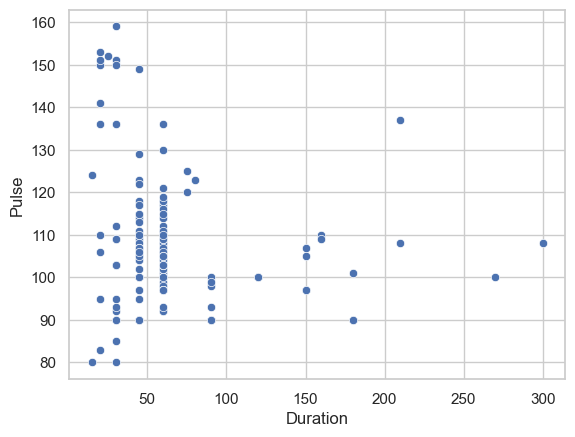

In [5]:
# Set whitegrid theme

sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df,
    x=df.columns[0],
    y=df.columns[1]
)

plt.show()

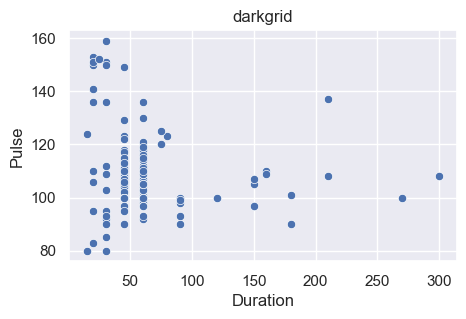

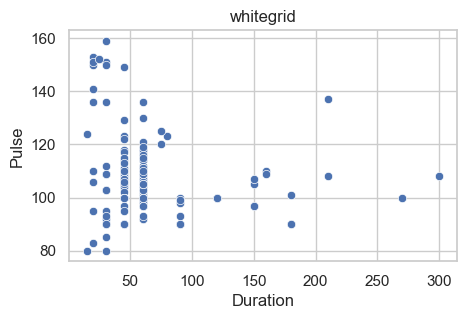

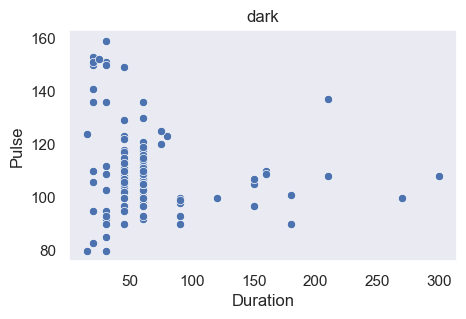

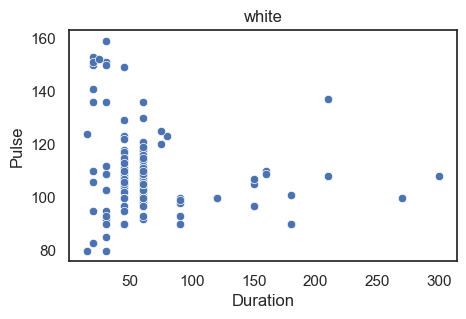

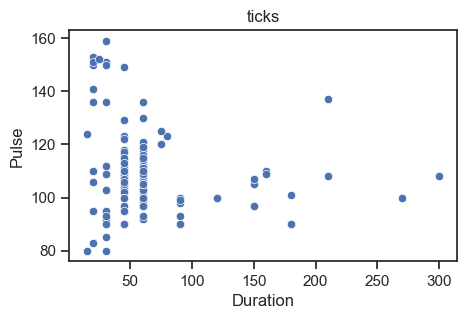

In [6]:
# Available themes

themes = ["darkgrid", "whitegrid", "dark", "white", "ticks"]

for theme in themes:

    sns.set_theme(style=theme)

    plt.figure(figsize=(5,3))

    sns.scatterplot(
        data=df,
        x=df.columns[0],
        y=df.columns[1]
    )

    plt.title(theme)

    plt.show()

# SECTION 2: COLOR PALETTES

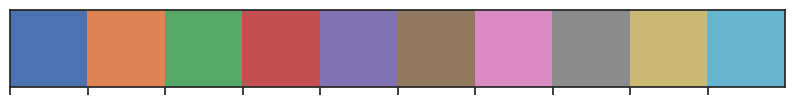

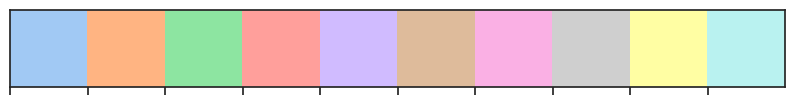

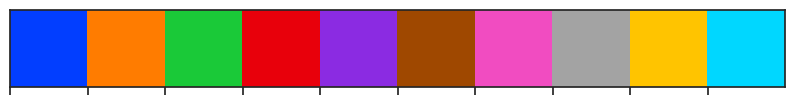

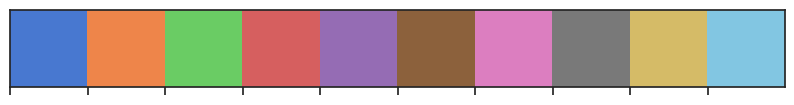

In [7]:
# Show popular palettes

sns.palplot(sns.color_palette("deep"))
plt.show()

sns.palplot(sns.color_palette("pastel"))
plt.show()

sns.palplot(sns.color_palette("bright"))
plt.show()

sns.palplot(sns.color_palette("muted"))
plt.show()

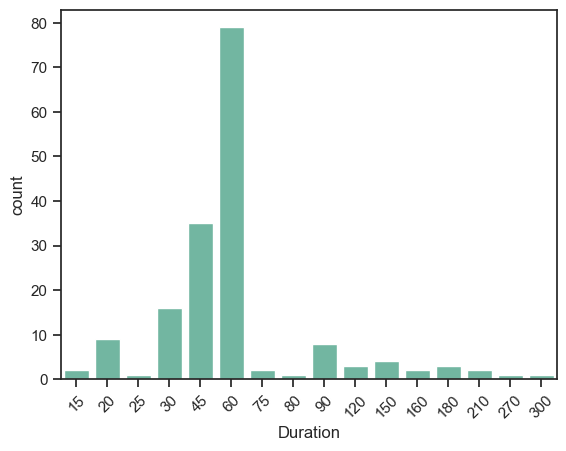

In [8]:
# Use a custom palette

sns.set_palette("Set2")

sns.countplot(
    data=df,
    x=df.columns[0]
)

plt.xticks(rotation=45)

plt.show()


 # SECTION 3: SCATTER PLOT

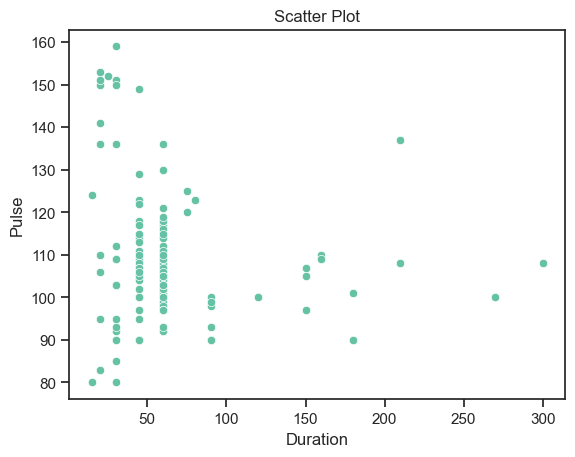

In [9]:
sns.scatterplot(
    data=df,
    x=df.columns[0],
    y=df.columns[1]
)

plt.title("Scatter Plot")

plt.show()

# SECTION 4: HISTOGRAM

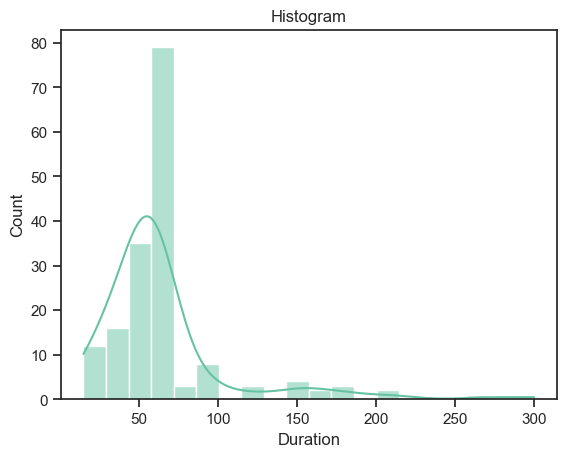

In [10]:
sns.histplot(
    data=df,
    x=df.columns[0],
    bins=20,
    kde=True
)

plt.title("Histogram")

plt.show()

## What is KDE?

### KDE = Kernel Density Estimation

### It shows a smooth curve representing the distribution.

## What are Bins
A bin is a range (interval) used to group numerical values in a histogram.<br>
Instead of showing every individual value, a histogram groups values into bins and counts how many observations fall into each bin.<br>
Suppose you have ages:  &  bins=3<br>
Seaborn might create ranges like:<br><hr>
| Bin Range | Count |
| --------- | ----- |
| 18–27     | 5     |
| 27–36     | 4     |
| 36–45     | 2     |


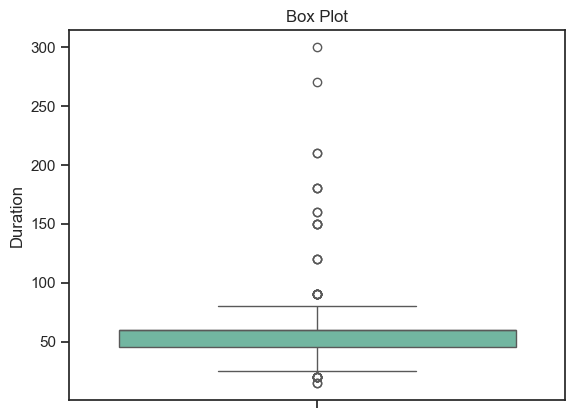

In [11]:
sns.boxplot(
    y=df[df.columns[0]]
)

plt.title("Box Plot")

plt.show()

### Interpretation
#### Box = IQR

#### Middle Line = Median

#### Dots Outside = Outliers

# SECTION 6: VIOLIN PLOT
### Why Violin Plot?
### Shows:
#### * Median
#### * Distribution
#### * Density
#### More informative than boxplot.

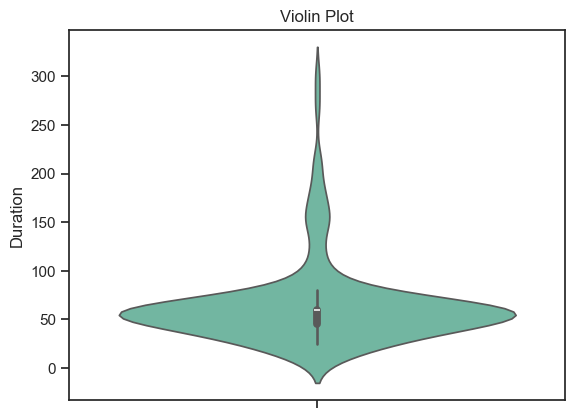

In [12]:
sns.violinplot(
    y=df[df.columns[0]]
)

plt.title("Violin Plot")

plt.show()

# SECTION 7: COUNTPLOT
##### Count frequency of categories.
<b>Example:<b>
* Male/Female
* City
* Department

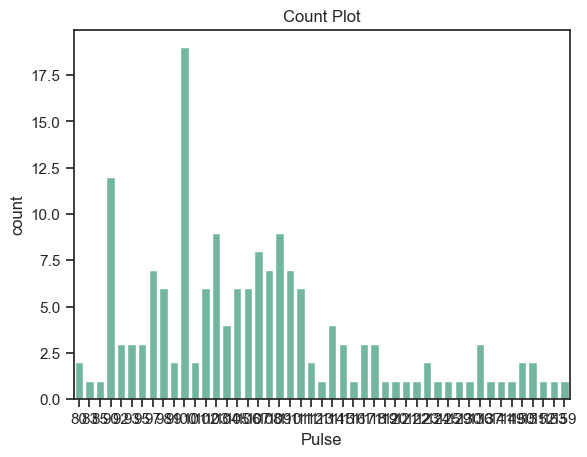

In [13]:
sns.countplot(
    data=df,
    x="Pulse"
)

plt.title("Count Plot")

plt.show()

# SECTION 8: BARPLOT WITH HUE
What does Hue do? <br>
Hue creates subgroups using color.

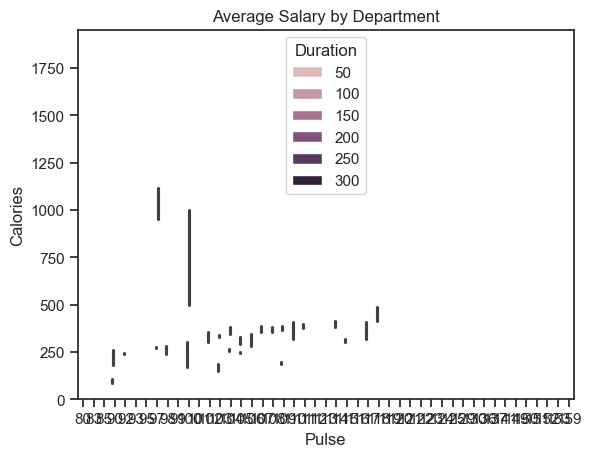

In [14]:
sns.barplot(
    data=df,
    x="Pulse",
    y="Calories",
    hue="Duration"
)

plt.title("Average Salary by Department")

plt.show()

# SECTION 9: HEATMAP

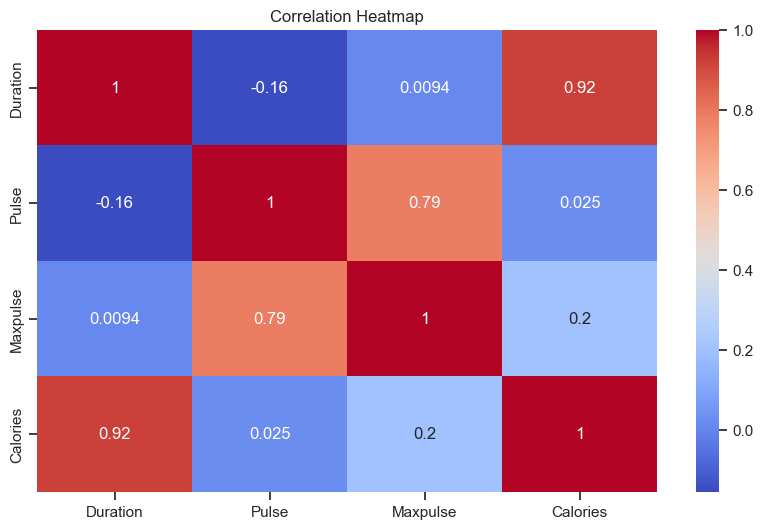

In [15]:
# Correlation matrix

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Interpretation
+1 = Strong Positive Relationship

0 = No Relationship

-1 = Strong Negative Relationship

# SECTION 10: PAIRPLOT

##### What Pairplot Shows
##### For every numeric column:
* Histogram on diagonal
* Scatterplots elsewhere
###### Excellent for EDA.

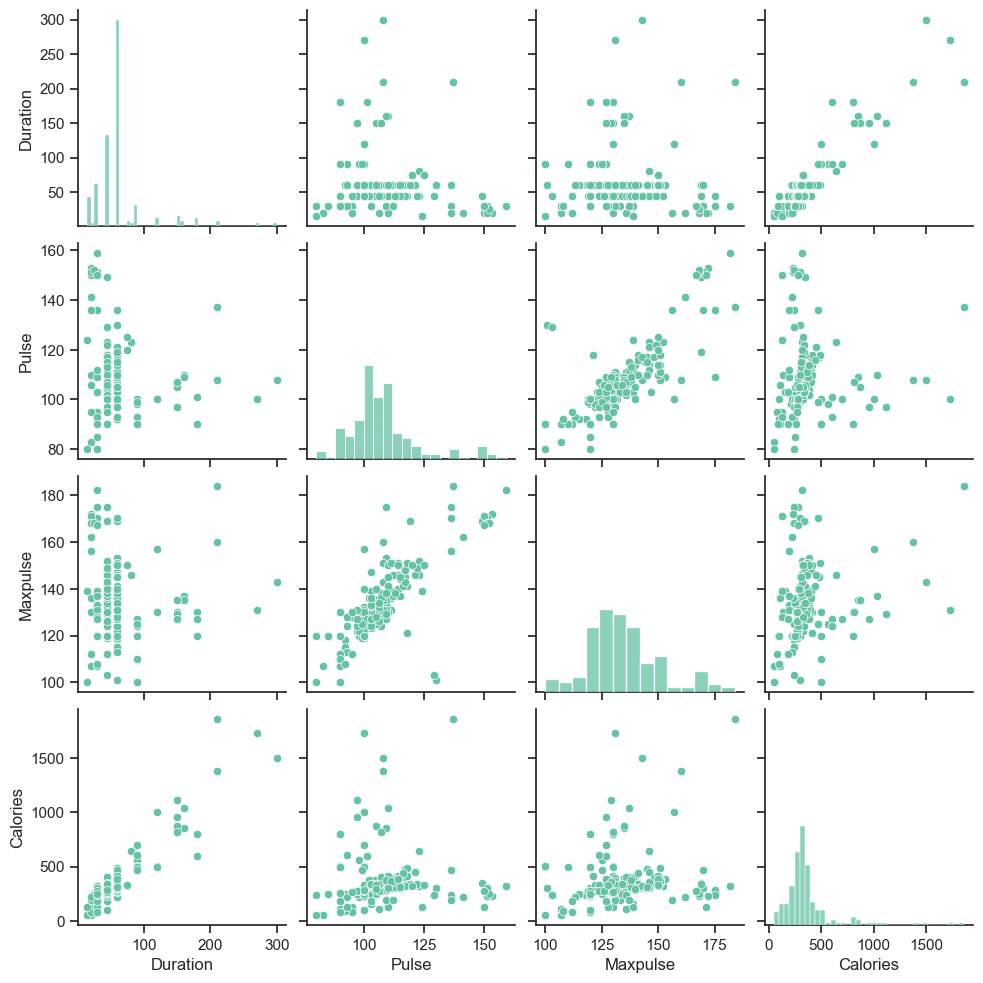

In [16]:
sns.pairplot(df)

plt.show()

# ADVANCED PAIRPLOT

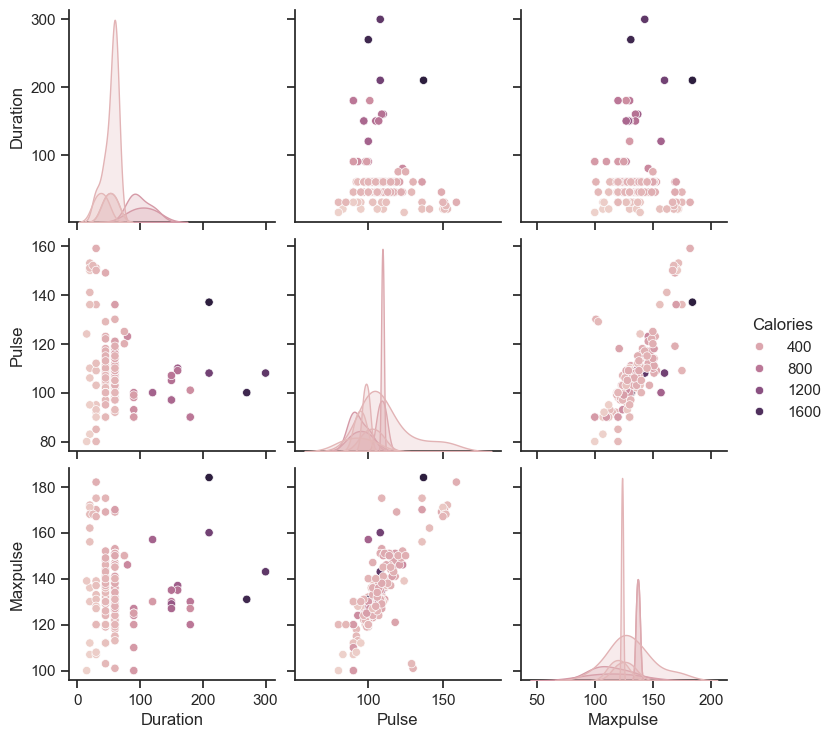

In [17]:
sns.pairplot(
    df,
    hue="Calories"
)

plt.show()

# VISUALIZATION BEST PRACTICES

# Best Practices

1. Always add titles.

2. Label axes.

3. Avoid too many colors.

4. Use readable font sizes.

5. Rotate crowded labels.

6. Avoid 3D charts.

7. Choose the correct chart:
   - Histogram → Distribution
   - Barplot → Comparison
   - Heatmap → Correlation
   - Pairplot → Exploration
   - Violin Plot → Distribution + Density

8. Keep visualizations simple.

# COLOR ACCESSIBILITY

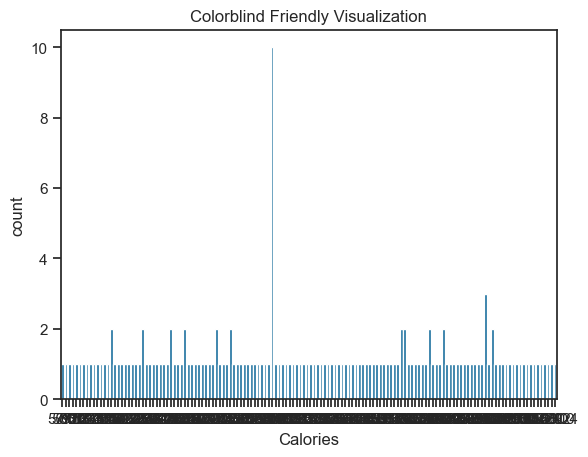

In [18]:
# Colorblind-friendly palette

sns.set_palette("colorblind")

sns.countplot(
    data=df,
    x="Calories"
)

plt.title("Colorblind Friendly Visualization")

plt.show()

# Why Accessibility Matters?

Approximately 8% of males have some form of color blindness.

Recommended palettes:

- colorblind
- deep
- Set2
- tab10

Avoid:

- Red vs Green only
- Too many bright colors

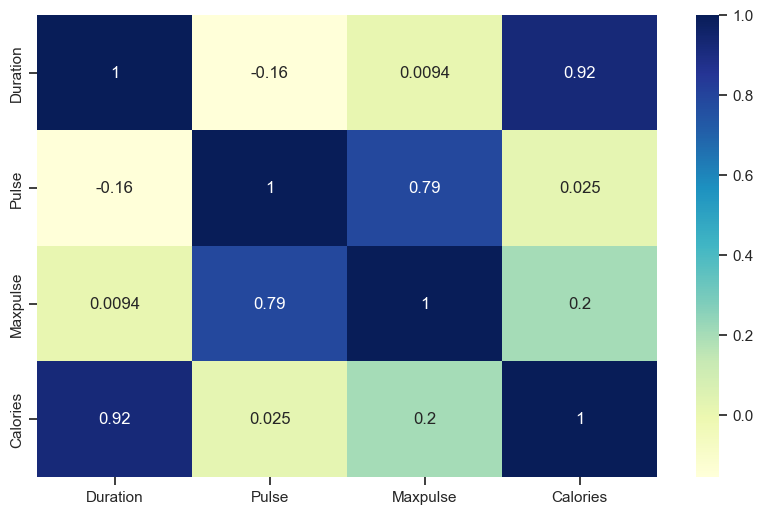

In [19]:
# 1. Correlation Heatmap

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu"
)

plt.show()

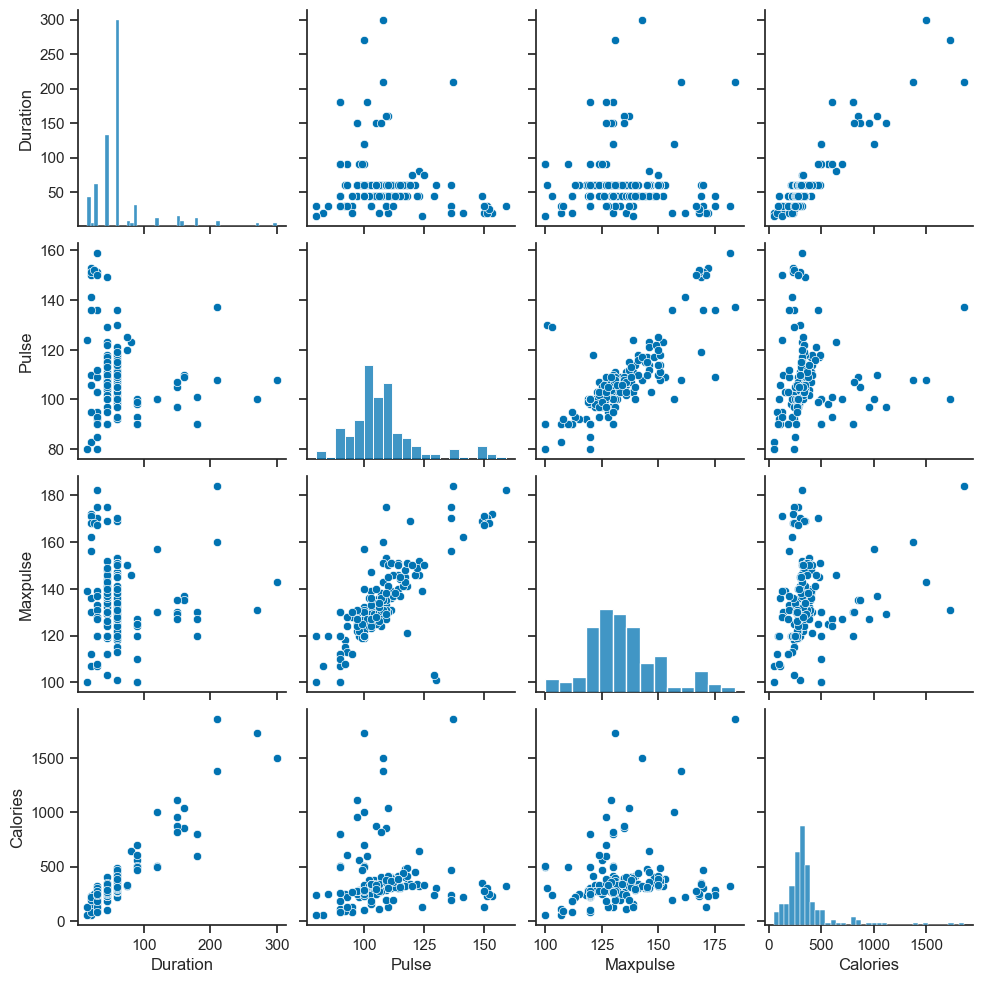

In [20]:
# 2. Pairplot

sns.pairplot(df)

plt.show()

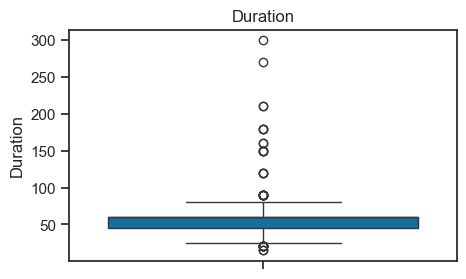

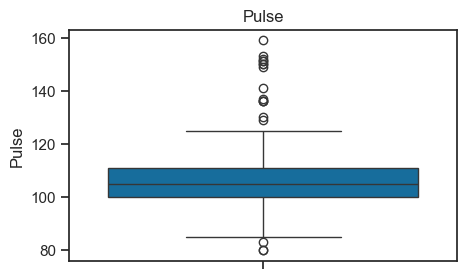

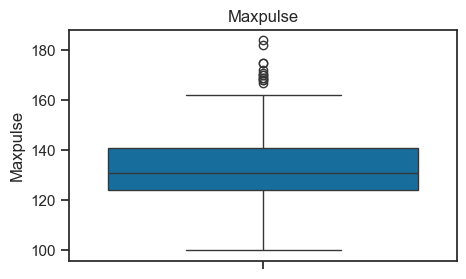

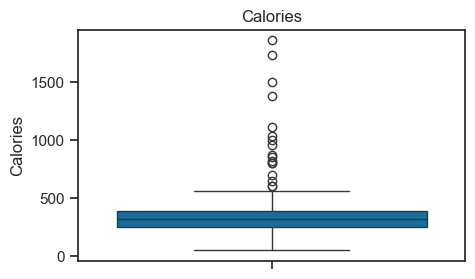

In [21]:
# 3. Boxplot for outliers

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:

    plt.figure(figsize=(5,3))

    sns.boxplot(y=df[col])

    plt.title(col)

    plt.show()

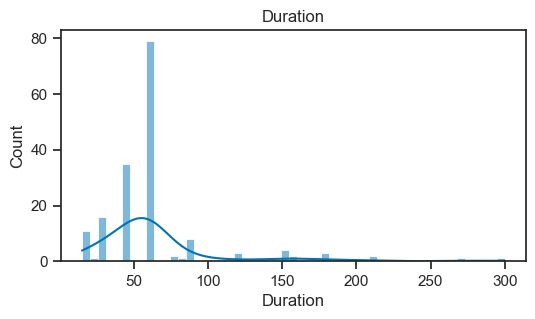

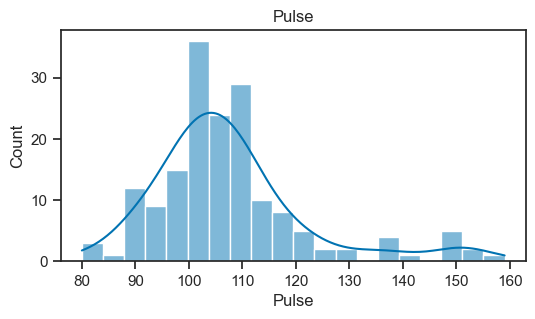

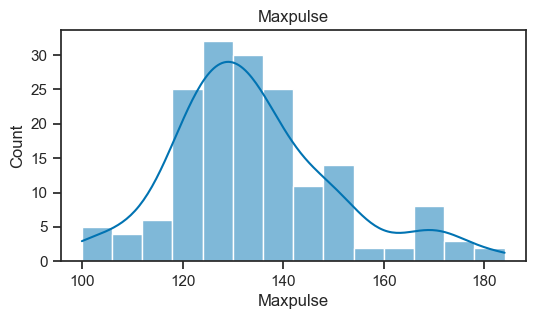

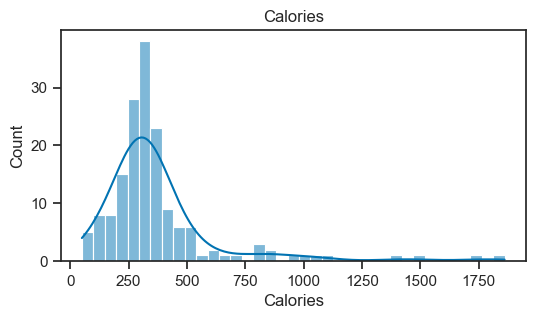

In [22]:
# 4. Distribution Analysis

for col in numeric_cols:

    plt.figure(figsize=(6,3))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()